In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager

# Train one agent for a single environment

In [2]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter [$lick\_cost, food\_reward, attention\_cost\_coeff, attention\_cost\_temp, penalty\_cost, iti\_cost$].

Checkpoint (epoch 50) loaded.
Fetching the most trained agent so far (epoch 50).
Agent (seed 0) was trained for 50 epochs, RL optimality 100.00%.


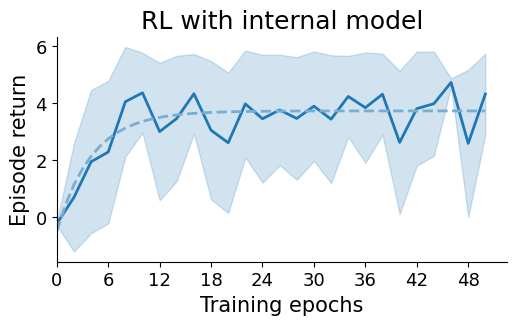

In [55]:
env_param = [0, 5, 0.005213, .25, -0.15, 0, 0]

# change back to old no. of epochs
num_epochs = 50

agent = manager.train_agent(env_param, num_epochs=num_epochs, seed = 0)
agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))

In [56]:
# weights_bias_dict = manager.agent_trained_wegihts_biases(env_param)
# from auditoryforage.utils import save_pickle_file

# print(f"biases are {weights_bias_dict['action_net_bias']}")
# print(f"weights are {weights_bias_dict['action_net_weight']}")
# label_font_size = 16



# for action_choice in range(len(weights_bias_dict['action_net_bias'])):
#     plt.figure()

#     # plt.stem(weights_bias_dict['action_net_weight'][action_choice][:-2])


#     signal_list = [elt  if ind!=0 else None for ind, elt in enumerate(weights_bias_dict['action_net_weight'][action_choice][:-2])]
#     noise_list = [elt  if ind==0 else None for ind, elt in enumerate(weights_bias_dict['action_net_weight'][action_choice][:-2])]
    
#     markerline, stemlines, baseline = plt.stem(signal_list, markerfmt = 'og')
#     plt.setp(baseline, linewidth = .5, color='black')
#     plt.setp(stemlines, linewidth = .2, color='g')
#     plt.setp(markerline, markersize='8')

#     markerline, stemlines, baseline = plt.stem(noise_list, markerfmt = 'or')
#     plt.setp(baseline, linewidth = .5, color='black')
#     plt.setp(stemlines, linewidth = .2, color='r')
#     plt.setp(markerline, markersize='8')
    
#     # plt.title(f'weights for actions {action_choice}')
#     plt.ylabel('weight', fontsize = label_font_size)
#     plt.xlabel('node index', fontsize = label_font_size)
#     plt.savefig(f'../slides_data/action_{action_choice}.png', bbox_inches='tight', pad_inches=0, dpi=300)
#     plt.show()

# plt.figure()
# plt.title(f'bias for actions excluding last one')
# plt.stem(weights_bias_dict['action_net_bias'])
# plt.xlabel('action index')
# plt.show()

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters.

problem somwhere here
[[3]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [3]]
(array([], dtype=int64), array([], dtype=int64))
problem somwhere here
[[3]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [3]]
(array([], dtype=int64), array([], dtype=int64))
average success streak is 1.0
average success rate is 0.03208739946170087
average episode time is 41.31372549019608


{'agent': {'lick_cost': 0,
  'food_reward': 5,
  'attention_cost_coeff': 0.005213,
  'attention_cost_temp': 0.25,
  'penalty_cost': -0.15,
  'iti_cost': 0,
  'time_in_game_reward': 0,
  'no_attention_modes': 2},
 'experiment': {'prob_01': 0.024,
  'no_signal_nodes': 25,
  'no_penalty_nodes': 1,
  'no_ITI_nodes': 1}}

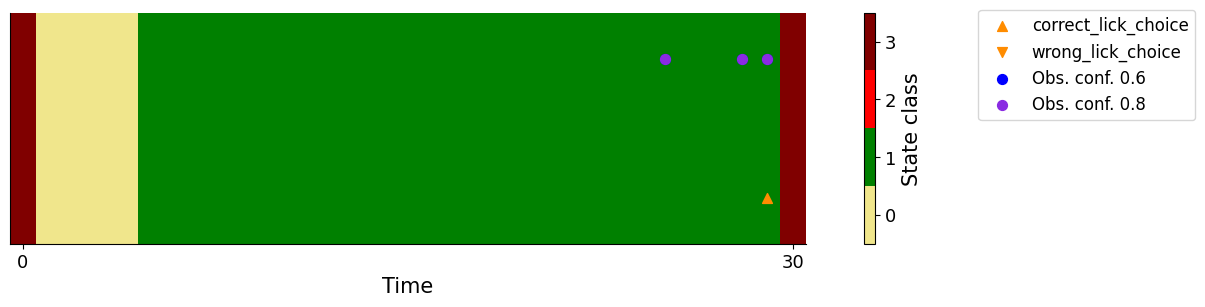

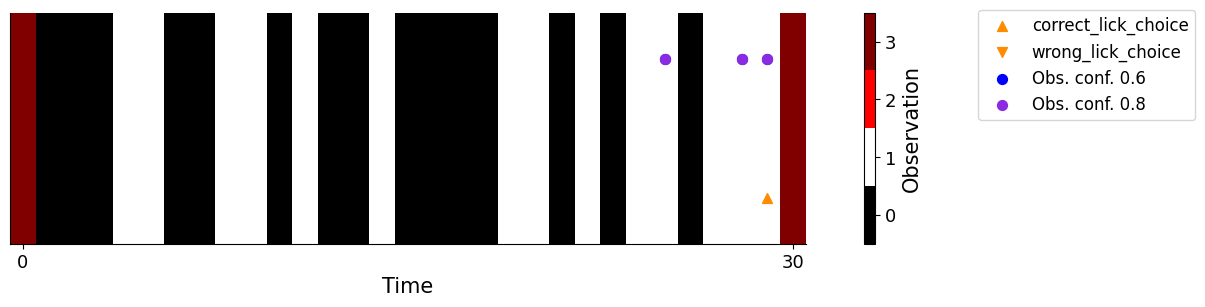

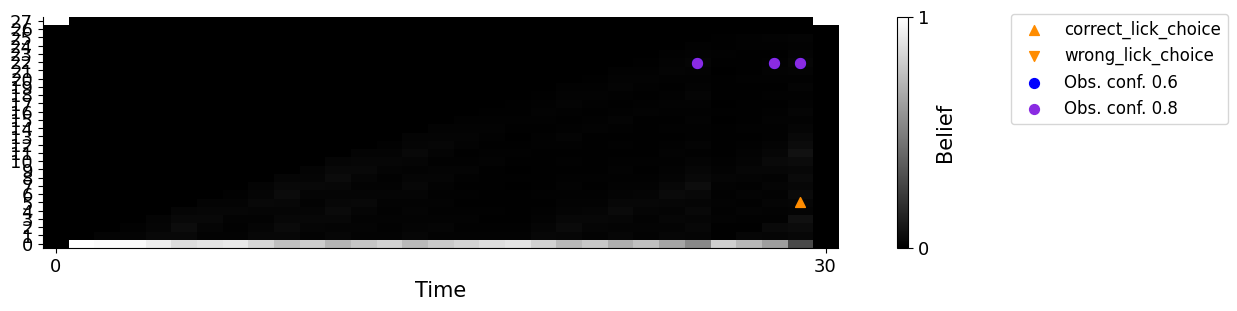

In [62]:
from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode

# Change below line if you want to try the trained model on a different set of environemnt.
# env_param = [-3.0, 8.0, 13, 8, -8, -4]

env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
fig = plot_AF_episode(episode, env, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

env.spec

In [63]:
import torch

def find_activation(agent, belief):

    # check whether gradient should be stopped while doing these
    
    features = torch.tensor(belief, dtype=torch.float32)

    with torch.no_grad():
        policy_net_0_results = agent.algo.policy.mlp_extractor.policy_net[0](features)
        policy_net_1_results = agent.algo.policy.mlp_extractor.policy_net[1](policy_net_0_results)
        policy_net_2_results = agent.algo.policy.mlp_extractor.policy_net[2](policy_net_1_results)
        policy_net_3_results = agent.algo.policy.mlp_extractor.policy_net[3](policy_net_2_results)
        policy_net_4_results = agent.algo.policy.mlp_extractor.policy_net[4](policy_net_3_results)
    
    # policy_net_4_results = agent.algo.policy.action_net(policy_net_3_results)

    return policy_net_4_results

activations_list = []
for belief in episode['beliefs'][:-1]: #Last belief is not used for action
    activations_list.append(find_activation(agent, belief).numpy())

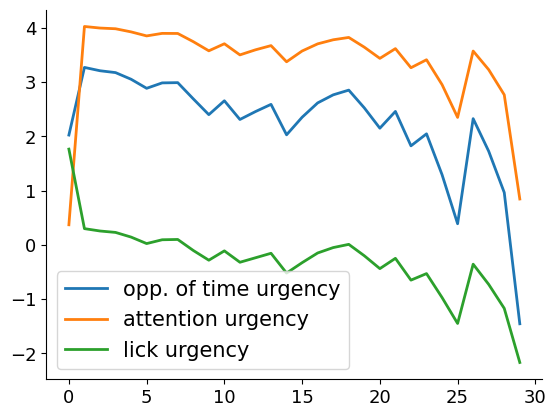

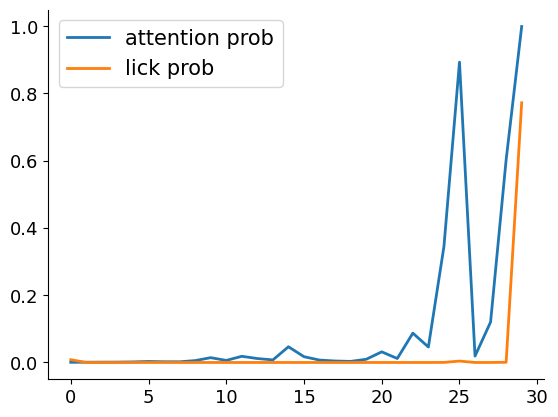

In [64]:
plt.plot([activations_list[ind][0] for ind in range(len(activations_list)) ], label = 'opp. of time urgency')
plt.plot([-activations_list[ind][1] for ind in range(len(activations_list)) ], label = 'attention urgency')
plt.plot([-activations_list[ind][2] for ind in range(len(activations_list)) ], label = 'lick urgency')
plt.legend()
plt.show()


lick_feature = [activations_list[ind][1] - activations_list[ind][0]  for ind in range(len(activations_list))]
attention_feature = [activations_list[ind][2] - activations_list[ind][0] for ind in range(len(activations_list))]
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature], label = 'lick prob')
plt.legend()
plt.show()


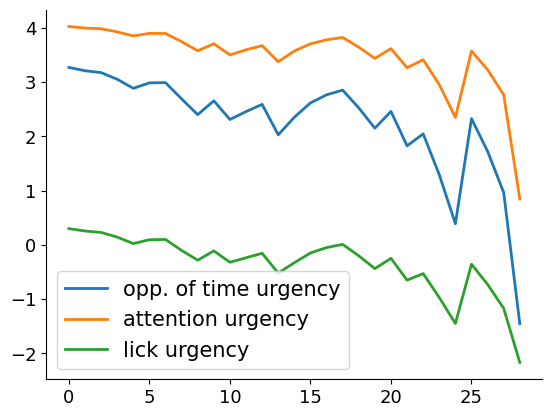

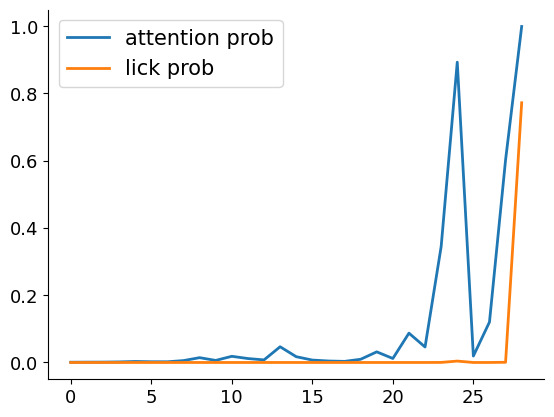

In [65]:
activations_list_ignore_0t = activations_list[1:]
plt.plot([activations_list_ignore_0t[ind][0] for ind in range(len(activations_list_ignore_0t)) ], label = 'opp. of time urgency')
plt.plot([-activations_list_ignore_0t[ind][1] for ind in range(len(activations_list_ignore_0t)) ], label = 'attention urgency')
plt.plot([-activations_list_ignore_0t[ind][2] for ind in range(len(activations_list_ignore_0t)) ], label = 'lick urgency')
plt.legend()
plt.show()


lick_feature = [activations_list_ignore_0t[ind][1] - activations_list_ignore_0t[ind][0]  for ind in range(len(activations_list_ignore_0t))]
attention_feature = [activations_list_ignore_0t[ind][2] - activations_list_ignore_0t[ind][0] for ind in range(len(activations_list_ignore_0t))]
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature], label = 'lick prob')
plt.legend()
plt.show()


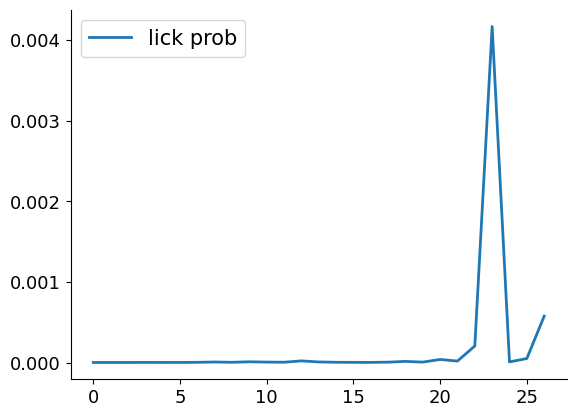

In [66]:
lick_feature = [activations_list_ignore_0t[ind][1] - activations_list_ignore_0t[ind][0]  for ind in range(len(activations_list_ignore_0t))]
attention_feature = [activations_list_ignore_0t[ind][2] - activations_list_ignore_0t[ind][0] for ind in range(len(activations_list_ignore_0t))]
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature][1:-1], label = 'lick prob')
plt.legend()
plt.show()


In [53]:
episode['beliefs'][-1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

In [54]:
len(episode['states'])

47

In [ ]:
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature][1:], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature][1:], label = 'lick prob')
plt.legend()
plt.show()

In [ ]:
plt.plot([policy_net_6_results_list[ind][0] for ind in range(len(policy_net_6_results_list)) ][1:], label = 'opp. of time urgency')

In [ ]:
def count_no_elements(np_array, min_allowed, max_allowed):
    return len([elt for elt in list(np_array.flatten()) if elt >= min_allowed and elt <= max_allowed])

episode['states'].flatten()
print(list(episode['states'].flatten()).count(0))
print(count_no_elements(episode['states'], 0, 0))

noise_time_before_lick = count_no_elements(episode['states'], 0, 0)
signal_time_before_lick = count_no_elements(episode['states'], 1, env.no_signal_nodes)
total_noise_time = count_no_elements(episode['states'], 0, 0)
total_signal_time = count_no_elements(episode['states'], 1, env.no_signal_nodes)

In [ ]:
# from auditoryforage.utils import save_pickle_file
# file_name = './auditoryforage/filters/ref_episode_13_5.pkl'
# save_pickle_file(episode, file_name)

### Jump start

In [ ]:
from auditoryforage.utils import open_pickle_file, save_pickle_file
file_name = './auditoryforage/filters/ref_episode_0.08_0.25.pkl'
# save_pickle_file(episode, file_name)
episode = open_pickle_file(file_name)

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from irc.manager import IRCManager
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)
from auditoryforage.AF_env import AuditoryForaging
env_param = [-3.0, 200.0, .08, .25, -5000, 0]
env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})

# Load multiple agents

In [ ]:
env_param_list = []
# env_param_list.append([-3.0, 200.0, .08, .25, -5000, 0])
# env_param_list.append([-3.0, 200.0, .08, .25, -5000, 0])

env_param_list.append([-3.0, 200.0, 13, 5, -5000, 0])
env_param_list.append([-3.0, 200.0, .06, .25, -5000, 0])
env_param_list.append([-3.0, 200.0, .08, .25, -5000, 0])

num_epochs = 400
num_epochs_list = [num_epochs] * len(env_param_list)

agent_list = []
for ind in range(len(env_param_list)):
    agent_list.append(manager.train_agent(env_param_list[ind], num_epochs=num_epochs_list[ind]))

# Particle filter

## Running Particle filter

### Latent  variable - only attention

In [ ]:
from auditoryforage.filters.PF_attention import ParticleFilter
end_index = 2
no_particles_list = [10000]
sampling_freq_list = [1]
particle_filter = ParticleFilter(agent, env)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

### Latent  variable - attention, and observation

In [ ]:
from auditoryforage.filters.PF_att_obs import ParticleFilter
end_index = 2
no_particles_list = [10000]
sampling_freq_list = [1]
particle_filter = ParticleFilter(agent, env)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

### Latent  variable - attention, and agents

In [ ]:
from auditoryforage.filters.PF_att_agent import ParticleFilter
end_index = 2
no_particles_list = [1000]
sampling_freq_list = [1]
true_params_folder_name = ''
particle_filter = ParticleFilter(agent_list, env_param_list, env, true_params_folder_name)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

### Latent  variable - agents

In [ ]:
from auditoryforage.filters.PF_agent import ParticleFilter
end_index = 2
no_particles_list = [1000]
sampling_freq_list = [1]
true_params_folder_name = ''
particle_filter = ParticleFilter(agent_list, env_param_list, env, true_params_folder_name)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

## Particle filter generated episode

### Latent  variable - only attention

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_35.pkl'

from auditoryforage.filters.PF_attention import ParticleFilter
PF_folder = 'store/filters/PF_attention/'
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
particle_filter = ParticleFilter(agent, env)
particle_filter.plot_generated_episode(file_name = PF_file_name, likelihood_rank = likelihood_rank)

## Analyzing particle filter output.

### Latent  variable - only attention

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_35.pkl'

from auditoryforage.filters.PF_attention import PF_results_analyzer
PF_folder = 'store/filters/PF_attention/'
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

### Latent  variable - attention, and observation

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_8.pkl'

from auditoryforage.filters.PF_att_obs import PF_results_analyzer
PF_folder = 'store/filters/PF_att_obs/'
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

### Latent  variable - attention, and agents

In [ ]:
# PF_file = 'PF_np_30000_sf_1_ei_100_rn_24.pkl'
PF_file = 'PF_np_100_sf_1_ei_1000_rn_63.pkl'
true_params_folder_name = ''

from auditoryforage.filters.PF_att_agent import PF_results_analyzer
PF_folder = 'store/filters/PF_att_agent/' + true_params_folder_name
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

### Latent  variable - agents

In [ ]:
# env_param_list.append([-3.0, 200.0, 13, 5, -5000, 0])
# env_param_list.append([-3.0, 200.0, .06, .25, -5000, 0])
# env_param_list.append([-3.0, 200.0, .08, .25, -5000, 0])

# true_params_folder_name = '0-13_5/'
# PF_file = 'PF_np_30000_sf_1_ei_3080_rn_97.pkl'

# true_params_folder_name = '1-0.06_0.25/'
# PF_file = 'PF_np_30000_sf_1_ei_846_rn_66.pkl'

true_params_folder_name = '2-0.08_0.25/'
# PF_file = 'PF_np_30000_sf_1_ei_100_rn_24.pkl'
# PF_file = 'PF_np_100_sf_1_ei_1000_rn_63.pkl'
# PF_file = 'PF_np_1000_sf_1_ei_1000_rn_82.pkl'
# PF_file = 'PF_np_10000_sf_1_ei_1000_rn_92.pkl'
PF_file = 'PF_np_30000_sf_1_ei_2000_rn_39.pkl'

from auditoryforage.filters.PF_agent import PF_results_analyzer
PF_folder = 'store/filters/PF_agent/' + true_params_folder_name
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

## Running HMM.

### Latent  variable - only attention

In [ ]:
from auditoryforage.filters.HMM_attention import HMM
end_index = 2
HMM_IO = HMM(agent, env, episode, end_index).compute_posterior_across_attention_series()

### Latent  variable - attention, and observation

In [ ]:
from auditoryforage.filters.HMM_att_obs import HMM
end_index = 2
HMM_IO = HMM(agent, env, episode, end_index).compute_posterior_across_attention_obs_series()

## Comparing particle filter and HMM outputs.

### Latent  variable - only attention

In [ ]:
PF_file = 'PF_np_100000_sf_1_ei_5_rn_66.pkl'
HMM_file = 'HMM_ei_5_rn_44.pkl'

from auditoryforage.filters.HMM_attention import compare_PF_HMM
PF_folder = 'store/filters/PF_attention/'
HMM_folder = 'store/filters/HMM_attention/'
PF_file_name = PF_folder + PF_file
HMM_file_name = HMM_folder + HMM_file
compare_PF_HMM(PF_file_name = PF_file_name, HMM_file_name = HMM_file_name)

### Latent  variable - attention, and observation

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_8.pkl'
HMM_file = 'HMM_ei_2_rn_98.pkl'

from auditoryforage.filters.HMM_att_obs import compare_PF_HMM
PF_folder = 'store/filters/PF_att_obs/'
HMM_folder = 'store/filters/HMM_att_obs/'
PF_file_name = PF_folder + PF_file
HMM_file_name = HMM_folder + HMM_file
compare_PF_HMM(PF_file_name = PF_file_name, HMM_file_name = HMM_file_name)

## Verifying if saved files makes sense

In [ ]:
from auditoryforage.utils import open_pickle_file, save_pickle_file

### Latent  variable - only attention

#### PF

In [ ]:
PF_file = 'PF_np_100000_sf_1_ei_5_rn_66.pkl'
PF_folder = 'store/filters/PF_attention/'
PF_file_name = PF_folder + PF_file
PF_IO = open_pickle_file(PF_file_name)

#### HMM

In [ ]:
HMM_file = 'HMM_ei_5_rn_44.pkl'
HMM_folder = 'store/filters/HMM_attention/'
HMM_file_name = HMM_folder + HMM_file
HMM_IO = open_pickle_file(PF_file_name)

### Latent  variable - attention, and observation

#### PF

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_8.pkl'
PF_folder = 'store/filters/PF_att_obs/'
PF_file_name = PF_folder + PF_file
PF_IO = open_pickle_file(PF_file_name)

#### HMM

In [ ]:
HMM_file = 'HMM_ei_2_rn_98.pkl'
HMM_folder = 'store/filters/HMM_att_obs/'
HMM_file_name = HMM_folder + HMM_file
HMM_IO = open_pickle_file(PF_file_name)

### Latent  variable - attention, and agents

#### PF

In [ ]:
PF_file = 'PF_np_30000_sf_1_ei_100_rn_24.pkl'
PF_folder = 'store/filters/PF_att_agent/'
PF_file_name = PF_folder + PF_file
PF_IO = open_pickle_file(PF_file_name)

In [ ]:
PF_IO['output']['sorted_results']['agent']['agent_ranked']

### Latent  variable - agents

In [ ]:
# PF_file = 'PF_np_30000_sf_1_ei_2205_rn_36.pkl'
# true_params_folder_name = '/high_en_2_tn_0_fr_350_ac_0.08_0.25/'

# PF_file = 'PF_np_30000_sf_1_ei_5315_rn_97.pkl'
# true_params_folder_name = '/low_en_2_tn_2_fr_50_ac_0.08_0.25/'

# PF_file = 'PF_np_30000_sf_1_ei_2205_rn_36.pkl'
# true_params_folder_name = '/high_en_2_tn_0_fr_100_ac_0.08_0.25/'

PF_folder = 'store/filters/PF_agent/' + true_params_folder_name
PF_file_name = PF_folder + PF_file
PF_IO = open_pickle_file(PF_file_name)
print(PF_IO['output']['sorted_results']['agent'])


## Summary results for a mice

In [ ]:
import os
results = []
main_dir = './store/filters/PF_agent/high_fr_350.0_ac_0.08_0.25'
for folder_name in os.listdir(main_dir):
    for file_name in os.listdir(main_dir + '/' + folder_name):
        results.append(open_pickle_file(main_dir + '/' + folder_name + '/' + file_name)['output']['sorted_results']['agent'])

## Deciding good att cost temp

In [ ]:
y = x1 * (np.exp(a/x2) - 1)
x2 = 1
x1 = y/(np.exp(a) - 1)

In [ ]:
import numpy as np
.08 * (np.exp(.9/.25) - 1)

In [ ]:
(np.exp(.9) - 1)

In [ ]:
0.6851177504050078 * (np.exp(.9) - 1)

In [ ]:
0.3425588752025039 * (np.exp(.9) - 1)

In [ ]:
0.06851177504050078 * (np.exp(.9) - 1)

In [ ]:
0.006851177504050078 * (np.exp(.9) - 1)

In [ ]:
y = x1 * (np.exp(a/x2) - 1)
x2 = 1
x1 = y/(np.exp(a) - 1)